# EDA: `Measurements.csv`

Exploratory data analysis of the wellness screening measurements dataset.

**Focus (per Pulse80 data engineering role):** grain integrity, missing-data patterns, validation/contract
coverage, unit consistency, and outlier/distribution diagnostics — the checks that determine whether this
table is safe to key into downstream analytical models, rather than presentation-ready charts.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

data_path = next((path for root in [Path.cwd(), *Path.cwd().parents]
                  for path in [root / 'data-analytics/data/raw/Measurements.csv',
                               root / 'data/raw/Measurements.csv']
                  if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Place Measurements.csv in data-analytics/data/raw/')

df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Shape: 264 rows x 8 columns


,measurement_id,screening_id,metric_code,numeric_value,text_value,unit,validation_status,captured_at
0,MEA-0001,SCR-0001,systolic_bp,119.00,NaN,mmHg,valid,2026-06-18T07:09:00Z
1,MEA-0002,SCR-0001,diastolic_bp,73.00,NaN,mmHg,valid,2026-06-18T07:09:00Z
2,MEA-0003,SCR-0001,pulse_rate,64.00,NaN,bpm,valid,2026-06-18T07:09:00Z
3,MEA-0004,SCR-0002,height,1.75,NaN,m,valid,2026-06-18T07:13:00Z
4,MEA-0005,SCR-0002,weight,75.30,NaN,kg,valid,2026-06-18T07:13:00Z
5,MEA-0006,SCR-0002,bmi,24.60,NaN,kg/m2,valid,2026-06-18T07:13:00Z
6,MEA-0007,SCR-0003,glucose,4.20,NaN,mmol/L,valid,2026-06-18T07:17:00Z
7,MEA-0008,SCR-0004,total_cholesterol,3.70,NaN,mmol/L,valid,2026-06-18T07:21:00Z
8,MEA-0009,SCR-0005,stress_score,7.00,NaN,score,valid,2026-06-18T07:25:00Z
9,MEA-0010,SCR-0006,fitness_score,73.00,NaN,score,valid,2026-06-18T07:29:00Z


## 1. Structure & data types

The table is in **long/EAV format**: one row per `(screening_id, metric_code)` observation, rather than one
row per screening. This is a common source-system pattern — worth confirming before assuming any grain.

In [2]:
df.info()
print()
print("Dtypes:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   measurement_id     264 non-null    object 
 1   screening_id       264 non-null    object 
 2   metric_code        264 non-null    object 
 3   numeric_value      264 non-null    float64
 4   text_value         0 non-null      float64
 5   unit               264 non-null    object 
 6   validation_status  264 non-null    object 
 7   captured_at        264 non-null    object 
dtypes: float64(2), object(6)
memory usage: 16.6+ KB

Dtypes:
measurement_id        object
screening_id          object
metric_code           object
numeric_value        float64
text_value           float64
unit                  object
validation_status     object
captured_at           object
dtype: object


## 2. Missing data patterns

Diagnostic check before anything else: which columns are populated, and does `text_value` ever carry data
(distinguishing numeric vs. categorical/text metrics)?

In [3]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
missing_summary

,missing_count,missing_pct
measurement_id,0,0.0
screening_id,0,0.0
metric_code,0,0.0
numeric_value,0,0.0
text_value,264,100.0
unit,0,0.0
validation_status,0,0.0
captured_at,0,0.0


data-analytics/notebooks/eda/measurements/Measurements_EDA_1.ipynb:cell-6:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


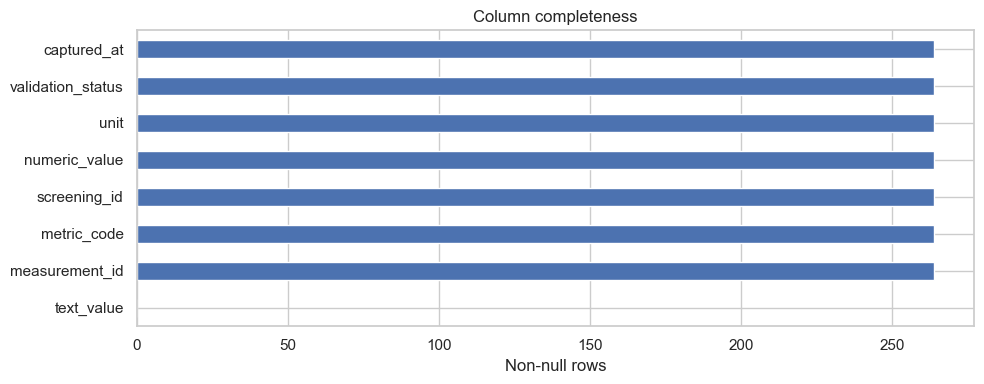

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
df.notna().sum().sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Non-null rows')
plt.title('Column completeness')
plt.tight_layout()
plt.show()

**Finding:** `text_value` is 100% null across all 264 rows. Every metric in this extract is numeric —
so either (a) this source never emits categorical/free-text measurements, or (b) text-valued metrics are
routed elsewhere upstream. Worth confirming against the data contract rather than assuming the column is
dead weight.

## 3. Grain integrity

Checking the primary key and the natural composite key before trusting any join or aggregation downstream.

In [5]:
# Primary key: measurement_id should be unique
dupe_ids = df['measurement_id'].duplicated().sum()
print(f"Duplicate measurement_id values: {dupe_ids}")

# Natural key: one (screening_id, metric_code) pair should appear once per screening event
dupe_natural_key = df.duplicated(subset=['screening_id', 'metric_code']).sum()
print(f"Duplicate (screening_id, metric_code) pairs: {dupe_natural_key}")

print(f"\nUnique screening_id count: {df['screening_id'].nunique()}")
print(f"Unique metric_code count: {df['metric_code'].nunique()}")
print(f"Rows per screening_id (should be consistent if every screening captures the full panel):")
print(df.groupby('screening_id').size().value_counts())

Duplicate measurement_id values: 0
Duplicate (screening_id, metric_code) pairs: 0

Unique screening_id count: 144
Unique metric_code count: 11
Rows per screening_id (should be consistent if every screening captures the full panel):
1    72
3    48
2    24
Name: count, dtype: int64


## 4. Metric coverage & validation status

Which metrics are present, how often, and does `validation_status` show any failed/pending records that
need to be excluded before aggregation?

validation_status
valid    264
Name: count, dtype: int64


data-analytics/notebooks/eda/measurements/Measurements_EDA_1.ipynb:cell-11:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


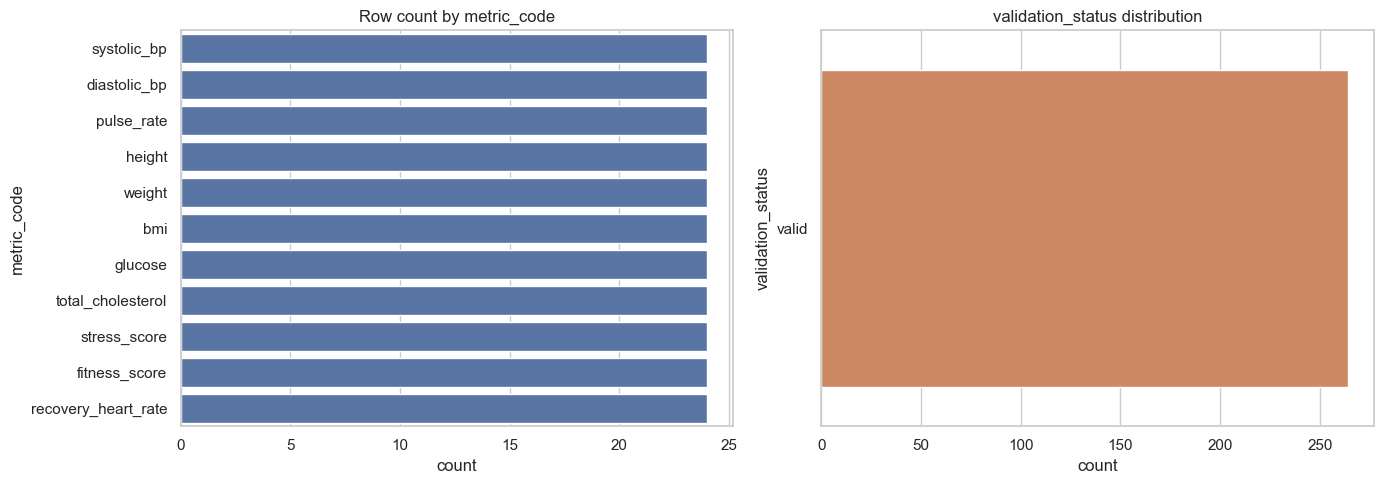

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_counts = df['metric_code'].value_counts()
sns.barplot(x=metric_counts.values, y=metric_counts.index, ax=axes[0], color='#4C72B0')
axes[0].set_title('Row count by metric_code')
axes[0].set_xlabel('count')

status_counts = df['validation_status'].value_counts()
sns.barplot(x=status_counts.values, y=status_counts.index, ax=axes[1], color='#DD8452')
axes[1].set_title('validation_status distribution')
axes[1].set_xlabel('count')

plt.tight_layout()
plt.show()
print(status_counts)

## 5. Unit consistency per metric

A single metric should map to exactly one unit. Any metric with >1 distinct unit is a red flag for
inconsistent source capture (e.g. imperial vs. metric height/weight) that would silently corrupt an
aggregate if unresolved.

In [7]:
unit_check = df.groupby('metric_code')['unit'].agg(['nunique', lambda x: sorted(x.unique())])
unit_check.columns = ['n_distinct_units', 'units']
unit_check

,n_distinct_units,units
metric_code,,
bmi,1,[kg/m2]
diastolic_bp,1,[mmHg]
fitness_score,1,[score]
glucose,1,[mmol/L]
height,1,[m]
pulse_rate,1,[bpm]
recovery_heart_rate,1,[bpm]
stress_score,1,[score]
systolic_bp,1,[mmHg]


## 6. Timestamp discipline

Confirming `captured_at` parses cleanly, checking timezone representation (UTC discipline matters for any
downstream `rolling()`/`shift()` window logic), and looking at the capture time range.

In [8]:
df['captured_at_parsed'] = pd.to_datetime(df['captured_at'], utc=True, errors='coerce')
n_unparseable = df['captured_at_parsed'].isna().sum()
print(f"Unparseable timestamps: {n_unparseable}")
print(f"Range: {df['captured_at_parsed'].min()}  ->  {df['captured_at_parsed'].max()}")

# Confirm every raw string is UTC ('Z' suffix) rather than mixed offsets
non_utc_suffix = (~df['captured_at'].str.endswith('Z')).sum()
print(f"Timestamps not using explicit 'Z' (UTC) suffix: {non_utc_suffix}")

Unparseable timestamps: 0
Range: 2026-06-18 07:01:00+00:00  ->  2026-06-18 09:59:00+00:00
Timestamps not using explicit 'Z' (UTC) suffix: 0


## 7. Reshape to wide (screening-level) grain

For distribution/outlier/correlation analysis it's more useful to pivot to one row per `screening_id`,
mirroring how this would land as a fact/dimension table downstream.

In [9]:
wide = df.pivot_table(index='screening_id', columns='metric_code', values='numeric_value', aggfunc='first')
print(f"Wide shape: {wide.shape}")
wide.head(10)

Wide shape: (144, 11)


metric_code,bmi,diastolic_bp,fitness_score,glucose,height,pulse_rate,recovery_heart_rate,stress_score,systolic_bp,total_cholesterol,weight
screening_id,,,,,,,,,,,
SCR-0001,NaN,73.0,NaN,NaN,NaN,64.0,NaN,NaN,119.0,NaN,NaN
SCR-0002,24.6,NaN,NaN,NaN,1.75,NaN,NaN,NaN,NaN,NaN,75.3
SCR-0003,NaN,NaN,NaN,4.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCR-0004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN
SCR-0005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN
SCR-0006,NaN,NaN,73.0,NaN,NaN,NaN,99.0,NaN,NaN,NaN,NaN
SCR-0007,NaN,71.0,NaN,NaN,NaN,59.0,NaN,NaN,131.0,NaN,NaN
SCR-0008,40.2,NaN,NaN,NaN,1.55,NaN,NaN,NaN,NaN,NaN,96.5
SCR-0009,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
wide.describe().T

,count,mean,std,min,25%,50%,75%,max
metric_code,,,,,,,,
bmi,24.0,28.262500,6.943612,18.60,23.2250,26.750,32.7750,40.70
diastolic_bp,24.0,84.500000,9.079360,71.00,77.0000,83.000,91.0000,105.00
fitness_score,24.0,62.958333,16.286776,33.00,51.7500,62.000,74.0000,86.00
glucose,24.0,7.162500,1.639675,4.20,6.0000,7.100,8.0750,11.80
height,24.0,1.734167,0.088363,1.55,1.6875,1.755,1.8025,1.85
pulse_rate,24.0,78.375000,11.623860,58.00,69.5000,78.000,89.2500,97.00
recovery_heart_rate,24.0,93.666667,15.493804,74.00,80.0000,90.000,110.2500,120.00
stress_score,24.0,13.000000,3.635573,7.00,10.0000,13.000,15.2500,19.00
systolic_bp,24.0,134.125000,14.567123,113.00,122.0000,133.000,145.2500,168.00


## 8. Distribution & outlier diagnostics

Boxplots per metric (raw units differ, so plotted individually) to flag implausible values before they
reach a risk-indicator calculation.

data-analytics/notebooks/eda/measurements/Measurements_EDA_1.ipynb:cell-20:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


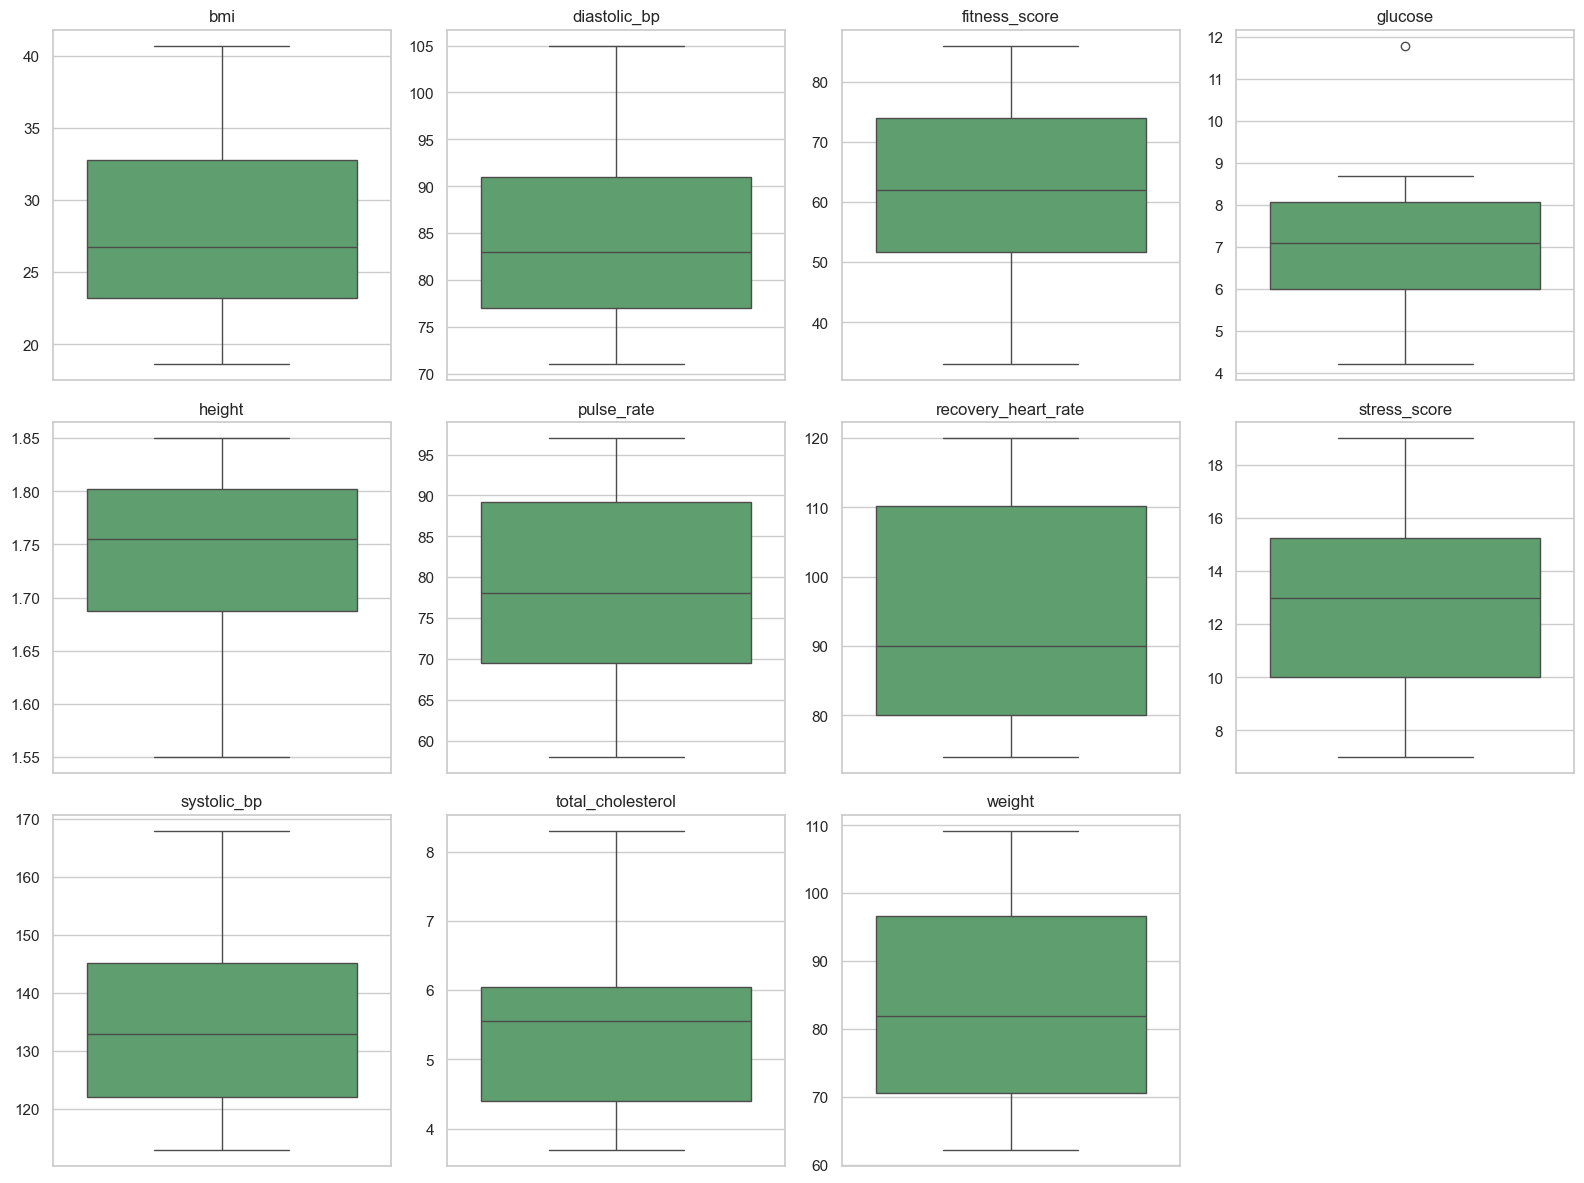

In [11]:
numeric_metrics = wide.columns.tolist()
n = len(numeric_metrics)
ncols = 4
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_metrics):
    sns.boxplot(y=wide[col].dropna(), ax=axes[i], color='#55A868')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
# IQR-based outlier flags per metric
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < lower) | (s > upper)]

print("IQR outlier counts per metric:")
for col in numeric_metrics:
    out = iqr_outliers(wide[col].dropna())
    print(f"  {col:22s}: {len(out)} outlier(s)" + (f"  -> values: {sorted(out.tolist())}" if len(out) else ""))

IQR outlier counts per metric:
  bmi                   : 0 outlier(s)
  diastolic_bp          : 0 outlier(s)
  fitness_score         : 0 outlier(s)
  glucose               : 1 outlier(s)  -> values: [11.8]
  height                : 0 outlier(s)
  pulse_rate            : 0 outlier(s)
  recovery_heart_rate   : 0 outlier(s)
  stress_score          : 0 outlier(s)
  systolic_bp           : 0 outlier(s)
  total_cholesterol     : 0 outlier(s)
  weight                : 0 outlier(s)


## 9. Plausibility sanity checks

Cross-checking a couple of derivable relationships that a clean dataset should satisfy e.g. BMI should be
internally consistent with height and weight (`bmi = weight / height^2`), and diastolic should not exceed
systolic.

In [13]:
bmi_check = wide.copy()
bmi_check['bmi_calculated'] = bmi_check['weight'] / (bmi_check['height'] ** 2)
bmi_check['bmi_diff'] = (bmi_check['bmi'] - bmi_check['bmi_calculated']).abs()

print("Rows where recorded bmi differs from calculated bmi by > 0.5:")
mismatch = bmi_check[bmi_check['bmi_diff'] > 0.5][['height', 'weight', 'bmi', 'bmi_calculated', 'bmi_diff']]
print(mismatch if len(mismatch) else "None found — bmi is internally consistent with height/weight.")

print()
bp_violation = wide[wide['diastolic_bp'] >= wide['systolic_bp']]
print("Rows where diastolic_bp >= systolic_bp (physiologically implausible):")
print(bp_violation[['systolic_bp', 'diastolic_bp']] if len(bp_violation) else "None found.")

Rows where recorded bmi differs from calculated bmi by > 0.5:
None found — bmi is internally consistent with height/weight.

Rows where diastolic_bp >= systolic_bp (physiologically implausible):
None found.


## 10. Correlation across metrics

Quick look at how the captured metrics relate to one another at the screening grain; useful context before
designing any composite risk indicator.

data-analytics/notebooks/eda/measurements/Measurements_EDA_1.ipynb:cell-25:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


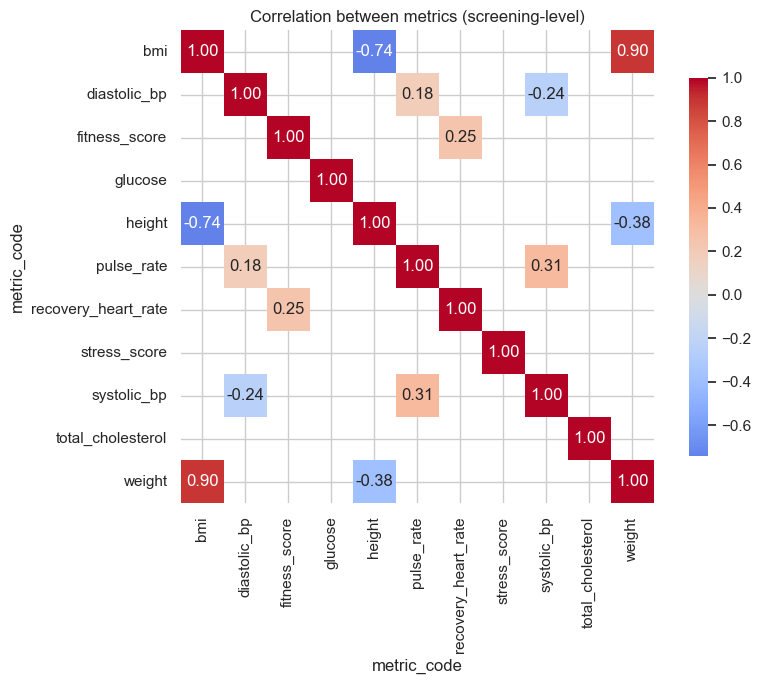

In [14]:
corr = wide.corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation between metrics (screening-level)')
plt.tight_layout()
plt.show()

## 11. Summary of findings

- **Grain:** table is EAV-style, one row per `(screening_id, metric_code)`; no duplicate `measurement_id`
  or duplicate natural-key pairs found in this extract; pivoting to a wide screening-level table is safe.
- **Completeness:** `numeric_value`, `unit`, `metric_code`, and `captured_at` are fully populated;
  `text_value` is entirely null in this extract (confirm against the contract whether that's expected).
- **Validation status:** check the printed distribution above; filter out anything other than `valid`
  before this feeds a metric calculation.
- **Units:** confirm every metric mapped to exactly one unit (see Section 5); if not, resolve before
  aggregating.
- **Timestamps:** confirm zero unparseable rows and explicit UTC (`Z`) suffixes (Section 6); required for
  safe `rolling()`/`shift()` windowing later.
- **Outliers / plausibility:** review the IQR flags and the BMI/blood-pressure consistency checks above;
  these are the values worth tracing back to source before they inform a risk score.

**Next steps:** compare `metric_code` coverage and validation rules against the Handbook's metric catalogue
and cohort-suppression thresholds before this table is exposed downstream.
